# Quiz 3

<font size='4'>
    
Class: BIOS-584 <br>
Time: 10-12 on Oct 31 <br>
Location: RRR 102 <br>

In [41]:
import os
# import numpy as np # this line is optional once you import Quiz3Fun
import pandas as pd
from self_py_fun.Quiz3Fun import *
import matplotlib.pyplot as plt
import scipy.stats as stats

<font size='4'>

You can leave if you finish it early. <br>
Make sure to show the line number for your Jupyter Notebook.<br>
The Quiz is open book and open notes, you can search relevant functions online, but you cannot use any AI tools.

## Q1. Pandas Data Analysis (1')

<font size='4'>

In this question, you are going to replicate part of the results from the research paper (Touponse et al, 2025). <br>
A copy of the published version is attached in the GitHub repository for your convenience. <br>
Section 2.4 may be helpful for you to select proper statistical tests.

In [3]:
print(os.getcwd())
ptsd_dir = '{}/data/PTSD dataset.xlsx'.format(os.getcwd())
ptsd_df = pd.read_excel(ptsd_dir, sheet_name='main_dataset')

E:\Git Hub\BIOS-584


### Q1.1 Descriptive Statistics and Univariate Comparison Stratified by Categorical Variable

<font size='4'>

Let's replicate part of Table 1 in Python. One categorical variable and one continuous variable are selected. <br>
You should show relevant codes to reflect the corresponding outputs.<br>
The variable for agreement group is coded as `caps_minuspcl_code`, you should be able to see the correspondence between levels and labels based on the sample size.<br>

For categorical variables, fill in both frequency and proportion of race variable, coded as `race_code`. <br>
Note that the proportion should be normalized by each column.<br>
For p-value, please refer to this tutorial: https://docs.scipy.org/doc/scipy/tutorial/stats/hypothesis_chi2_contingency.html#hypothesis-chi2-contingency.

| Patient characteristic     | Extensive Over-reporters  (n=83) | Limited Over-reporters  (n=325) | Congruent Reporters (n=75) | P-value |
|----------------------------|----------------------------------|---------------------------------|----------------------------|---------|
| Race, n (%)                |                                  |                                 |                            |         |
| White (1)                  |                                  |                                 |                            |         |
| Black (2)                  |                                  |                                 |                            |         |
| Asian/Pacific Islander (3) |                                  |                                 |                            |         |
| Native American (4)        |                                  |                                 |                            |         |
| Multi-racial (5)           |                                  |                                 |                            |         |
| Missing (6)                |                                  |                                 |                            |         |

In [5]:
# Relevant code to fill in race group in Table 1
# Defining variables
agreement_var = 'caps_minuspcl_code'
race_var = 'race_code'

# Define variable labels
race_labels = {
    1: 'White(1)',
    2: 'Black(2)',
    3: 'Asian/Pacific Islander(3)',
    4: 'Native American(4)',
    5: 'Multi-racial(5)',
    6: 'Missing(6)'
}

#sample sizes per group
group_sizes = ptsd_df[agreement_var].value_counts().sort_index()

# Define agreement labels
agreement_labels = {
    1: f'Extensive Over-reporters (n={group_sizes[1]})',
    2: f'Limited Over-reporters (n={group_sizes[2]})', 
    3: f'Congruent Reporters (n={group_sizes[3]})'
}

# Create table
table1 = pd.crosstab(ptsd_df[race_var], ptsd_df[agreement_var])

# Create the final table with n (%)
final_table = pd.DataFrame()

for group_code in sorted(table1.columns):
    freq = table1[group_code]
    prop = (table1[group_code] / table1[group_code].sum() * 100).round(1)
    
    # Format as "n (%)"
    final_table[agreement_labels[group_code]] = freq.astype(str) + ' (' + prop.astype(str) + '%)'

# Calculate p-value for each race category
p_values = []
for race_code in sorted(race_labels.keys()):
    # Create 2x3 table: this race vs all other races combined
    this_race = table1.loc[race_code].values
    other_races = table1.drop(race_code).sum().values
    
    # 2x3 contingency table
    test_table = np.array([this_race, other_races])
    
    # Chi-square test
    chi2, p_val, dof, expected = stats.chi2_contingency(test_table)
    p_values.append(p_val)

# Replace race codes with labels
final_table.index = [race_labels[i] for i in final_table.index]

# Add p-values column
final_table['p-value'] = [f'{p:.4f}' for p in p_values]

# Set the index name to "Patient Characteristic"
final_table.index.name = 'Patient Characteristic'

# Display
display(final_table)

,Extensive Over-reporters (n=83),Limited Over-reporters (n=325),Congruent Reporters (n=75),p-value
Patient Characteristic,,,,
White(1),30 (36.1%),190 (58.5%),50 (66.7%),0.0002
Black(2),32 (38.6%),97 (29.8%),15 (20.0%),0.0391
Asian/Pacific Islander(3),3 (3.6%),6 (1.8%),1 (1.3%),0.5332
Native American(4),1 (1.2%),2 (0.6%),0 (0.0%),0.6291
Multi-racial(5),5 (6.0%),5 (1.5%),1 (1.3%),0.0422
Missing(6),12 (14.5%),25 (7.7%),8 (10.7%),0.1516


<font size='4'>

For continouous variable, fill in mean and sd of PHQ-9 score at intake, coded as `phq9_score_intake`. <br>
For mean and std values stratified by a categorical variable, refer to this API page: https://pandas.pydata.org/pandas-docs/version/1.2/reference/api/pandas.core.groupby.GroupBy.mean.html <br>
Use `pd.DataFrame()` to create a new Pandas DataFrame to combine stratified mean and std values, denoted as `phq9_summary_df`. Rename column names as `phq9_mean` and `phq9_std`. <br>
<img src="figures/quiz3_q1.2.png" alt="drawing" width="400"/>

For p-value, please refer to the tutorial: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html#scipy.stats.f_oneway <br>
You may use the conditional slicing (Section 4.9 from week-09-pandas.ipynb)

| Patient characteristic     | Extensive Over-reporters  (n=83) | Limited Over-reporters  (n=325) | Congruent Reporters (n=75) | P-value |
|----------------------------|----------------------------------|---------------------------------|----------------------------|---------|
| Clinical Measures          |                                  |                                 |                            |         |
| PHQ9 score at intake, mean (SD)|                                  |                                 |                            |         |

In [9]:
# Relevant code to fill in PHQ-9 score at intake in Table 1
# Define variable
phq9_var = 'phq9_score_intake'

# Get group sizes and create labels
group_sizes = ptsd_df[agreement_var].value_counts().sort_index()
agreement_labels = {
    1: f'Extensive Over-reporters (n={group_sizes[1]})',
    2: f'Limited Over-reporters (n={group_sizes[2]})', 
    3: f'Congruent Reporters (n={group_sizes[3]})'
}

# Calculating mean and std using groupby
phq9_summary_df = pd.DataFrame({
    'phq9_mean': ptsd_df.groupby(agreement_var)[phq9_var].mean(),
    'phq9_std': ptsd_df.groupby(agreement_var)[phq9_var].std()
})

print("PHQ-9 Summary Statistics (phq9_summary_df):")
display(phq9_summary_df)


# Create formatted table with mean (SD)
final_phq9_table = pd.DataFrame()

for group_code in sorted(phq9_summary_df.index):
    mean_val = phq9_summary_df.loc[group_code, 'phq9_mean']
    std_val = phq9_summary_df.loc[group_code, 'phq9_std']
    final_phq9_table[agreement_labels[group_code]] = [f'{mean_val:.2f} ({std_val:.2f})']

# Perform one-way ANOVA using conditional slicing
# Conditional slicing: isolate rows where agreement_var equals specific values
group1 = ptsd_df[ptsd_df[agreement_var] == 1][phq9_var].dropna()
group2 = ptsd_df[ptsd_df[agreement_var] == 2][phq9_var].dropna()
group3 = ptsd_df[ptsd_df[agreement_var] == 3][phq9_var].dropna()

# One-way ANOVA
f_stat, p_value = stats.f_oneway(group1, group2, group3)

# Add p-value to table
final_phq9_table['P-value'] = [f'{p_value:.4f}']

# Create a header row for "Clinical Measures" with empty values
clinical_measures_row = pd.DataFrame(
    [[''] * len(final_phq9_table.columns)],
    columns=final_phq9_table.columns,
    index=['Clinical Measures']
)

# Set the PHQ-9 row index
final_phq9_table.index = ['PHQ9 score at intake, mean (SD)']

# Combining the header row and data row
final_table_with_header = pd.concat([clinical_measures_row, final_phq9_table])
final_table_with_header.index.name = 'Patient Characteristic'

# Display final table
print("\nPHQ9 Distribution by Agreement Group:")
display(final_table_with_header)

PHQ-9 Summary Statistics (phq9_summary_df):


,phq9_mean,phq9_std
caps_minuspcl_code,,
1,17.587500,4.667945
2,16.596215,5.128203
3,14.148649,5.711518



PHQ9 Distribution by Agreement Group:


,Extensive Over-reporters (n=83),Limited Over-reporters (n=325),Congruent Reporters (n=75),P-value
Patient Characteristic,,,,
Clinical Measures,,,,
"PHQ9 score at intake, mean (SD)",17.59 (4.67),16.60 (5.13),14.15 (5.71),0.0001


### Q1.2 Scatterplots

<font size='4'>

Then, let's replicate part of Figure 1 by creating two scatterplots between CAPS-5 Intake (`caps_intake`) and PCL-5 Intake (`pcl5_score_intake`) (left) as well as between PCL-5 Intake (`pcl5_score_intake`) and PCL-5 Baseline (`pcl5month_score.baseline`) (Right).<br>
You are asked to only create scatterplots, no need to add the linear trends.<br>
You are asked to create a subplot with two plots shown in the same row. <br>
Name x-, y-axes, and titles accordingly. <br>
Report Pearson correlation estimates and their p-values accordingly. You can put relevant information on the title. <br>
Read this API tutorial. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html 

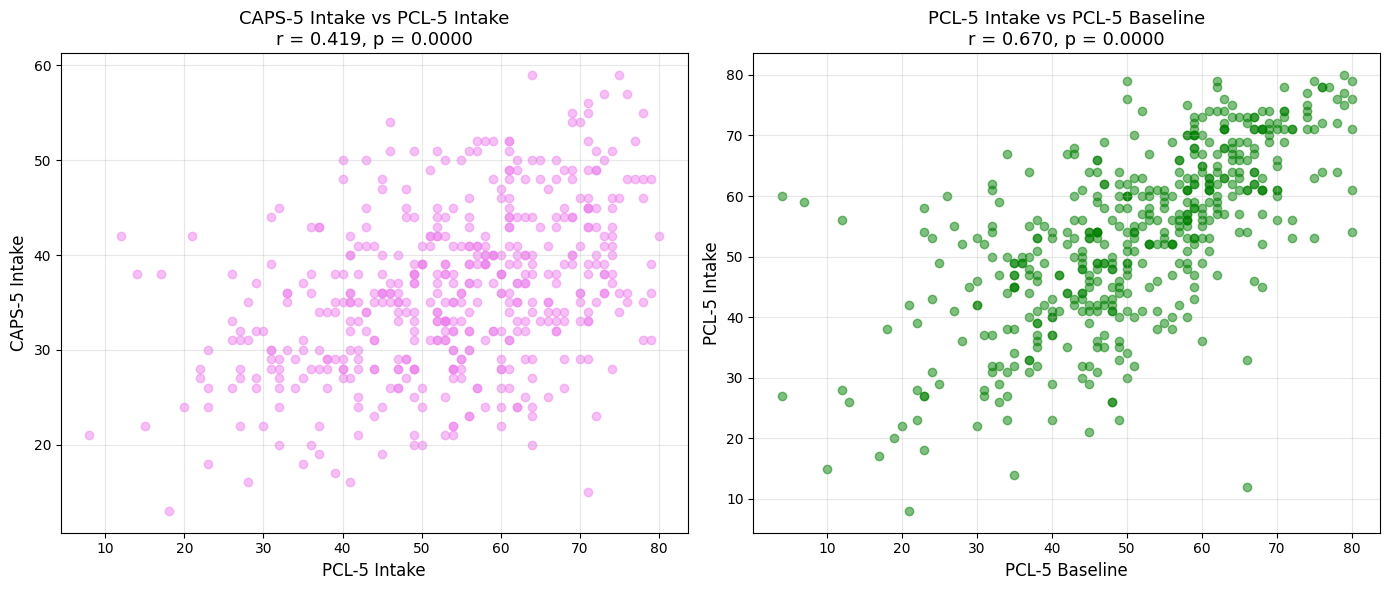

In [44]:
# write your own code below
# Define variables
caps_intake = 'caps_intake'
pcl5_intake = 'pcl5_score_intake'
pcl5_baseline = 'pcl5month_score.baseline'

# Prepare data for left plot (drop NA for both variables)
df_left = ptsd_df[[caps_intake, pcl5_intake]].dropna()
corr1, p_value1 = stats.pearsonr(df_left[caps_intake], df_left[pcl5_intake])

# Prepare data for right plot (drop NA for both variables)
df_right = ptsd_df[[pcl5_intake, pcl5_baseline]].dropna()
corr2, p_value2 = stats.pearsonr(df_right[pcl5_intake], df_right[pcl5_baseline])

# Creating subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: CAPS-5 Intake vs PCL-5 Intake
axes[0].scatter(df_left[pcl5_intake], df_left[caps_intake], alpha=0.5, color='violet')
axes[0].set_xlabel('PCL-5 Intake', fontsize=12)
axes[0].set_ylabel('CAPS-5 Intake', fontsize=12)
axes[0].set_title(f'CAPS-5 Intake vs PCL-5 Intake\nr = {corr1:.3f}, p = {p_value1:.4f}', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Right plot: PCL-5 Intake vs PCL-5 Baseline
axes[1].scatter(df_right[pcl5_baseline], df_right[pcl5_intake], alpha=0.5, color='green')
axes[1].set_xlabel('PCL-5 Baseline', fontsize=12)
axes[1].set_ylabel('PCL-5 Intake', fontsize=12)
axes[1].set_title(f'PCL-5 Intake vs PCL-5 Baseline\nr = {corr2:.3f}, p = {p_value2:.4f}', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Q1.3 Stratified Error Bars

<font size='4'>
    
Finally, let's replicate the left panel of Figure 2.<br>
Compute the mean and std values of PCL-5 score at baseline (`pcl5month_score.baseline`) and completion of IOP (`pcl5week_score.completion`) stratified by three agreement group (`caps_minuspcl_code`).<br>
Show changes in mean and one-std error bar values between baseline and completion. <br>
For error bar, please refer to the API page: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html. <br>

- Relevant optional parameters for `plt.errorbar()` include `label`, `marker`, `markersize`, `capsize`, and `loc`.
- You can add/minus a small value, i.e., 0.05, to the x-axis array such that three error bars are not overlapped with each other.
- Finally, you should modify the label of your x-axis array if you originally define your x-axis input as a numerical array.
    - Useful function to change the labels include `plt.xticks()`.
- Remember the correspondence as Extensive (1), Limited (2), and Congruent (3). 

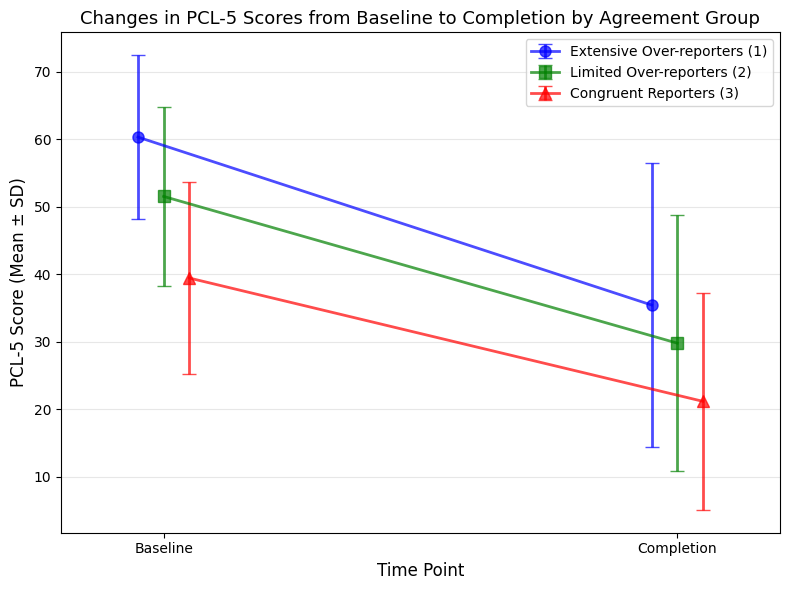

In [16]:
x_arr = np.array(['Baseline', 'Completion'])
x_arr_num = np.array([0, 1])

# write your own code
# Define variables
pcl5_baseline = 'pcl5month_score.baseline'
pcl5_completion = 'pcl5week_score.completion'
agreement_var = 'caps_minuspcl_code'

# Calculate mean and std for baseline stratified by agreement group
baseline_mean = ptsd_df.groupby(agreement_var)[pcl5_baseline].mean()
baseline_std = ptsd_df.groupby(agreement_var)[pcl5_baseline].std()

# Calculate mean and std for completion stratified by agreement group
completion_mean = ptsd_df.groupby(agreement_var)[pcl5_completion].mean()
completion_std = ptsd_df.groupby(agreement_var)[pcl5_completion].std()

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Colors, markers, and labels for each group
colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']
labels = ['Extensive Over-reporters (1)', 'Limited Over-reporters (2)', 'Congruent Reporters (3)']

# Plot each agreement group
for i, group_code in enumerate([1, 2, 3]):
    # Offset to prevent overlap: -0.05, 0, 0.05
    offset = (i - 1) * 0.05
    
    # X positions with offset
    x_positions = x_arr_num + offset
    
    # Y values (mean)
    y_values = [baseline_mean[group_code], completion_mean[group_code]]
    
    # Error values (std)
    error_values = [baseline_std[group_code], completion_std[group_code]]
    
    # Plot error bars
    ax.errorbar(x_positions, y_values, yerr=error_values,
                marker=markers[i], markersize=8, capsize=5,
                color=colors[i], label=labels[i],
                linestyle='-', linewidth=2, alpha=0.7)

# Set x-axis labels using plt.xticks()
plt.xticks(x_arr_num, x_arr)

# Labels and formatting
ax.set_xlabel('Time Point', fontsize=12)
ax.set_ylabel('PCL-5 Score (Mean ± SD)', fontsize=12)
ax.set_title('Changes in PCL-5 Scores from Baseline to Completion by Agreement Group', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(-0.2, 1.2)

plt.tight_layout()
plt.show()

## Q2. Debugging Example (1')

<font size='4'>

Given a 1-dim signal input $x$ with $T$ data points and $i$ being its index, compute the following function value $D$ such that 
$$D =  \sum_{i=1}^{T-1} \sqrt{1+ (x_i - x_{i+1})^2},$$
where $x_i-x_{i+1}$ is the first-order difference and $i$ ranges from $1$ to $T-1$. <br>
* You have learned the notation $\sqrt{\cdot}$ previously as the operator of square root. <br>
* For $\sum$, if you haven't used it before, it is known as cumulative summation. For example, $\sum_{i=1}^5 a_i = a_1 + a_2 + a_3 + a_4 + a_5$. If $a_i=i$, then the sum is simply $1+2+3+4+5=15$.


I have created a partially written function `compute_D_partial` with a parameter of `input_signal` and returning value `D_val`. However, there are **two typos** such that the outputs of sample input arrays are incorrect. <br>
In particular, for `sample_arr_1`, the incorrect `D` is $1.95$, while the correct `D` should be $5.66$.

1. Find two typos in the original function and comment on the mistake. You can perform debugging task using `Quiz3_main.py`. To make my grading easier, another function `compute_D_partial_for_task_1_only` is attached below. Write a comment right after the line that you think is incorrect to briefly explain the typo.
2. After spotting the typos, write a new function called `compute_D_correct` on `Quiz3Fun.py`. 
3. Call the correct function (`compute_D_correct`) with `sample_arr_2` and print out the correct D value, denoted as `d_val_2`.

In [18]:
# your solution to 1.
def compute_D_partial_for_task_1_only(input_signal):
    r"""
    :param input_signal:
    """
    T_len = len(input_signal)
    signal_diff_one = input_signal[:-1] - input_signal[1:] 
    D_val = np.sum(np.sqrt(1+signal_diff_one**2))
    return D_val

#Typo 1 in the original function (compute_D_partial):
# MISTAKE: input_signal[-1] only takes the last element, not all elements except the last.
# Instead, it should be written as "input_signal[:-1]" to get all elements from index 0 to T-2.
# Correct line is: signal_diff_one = input_signal[:-1] - input_signal[1:]

# Typo 2 in the original function (compute_D_partial):
# MISTAKE: formula does not require any division as there is no denominator. Dividing by (T_len - 1) is incorrect.
# Correct line is: D_val = np.sum(np.sqrt(1+signal_diff_one**2))

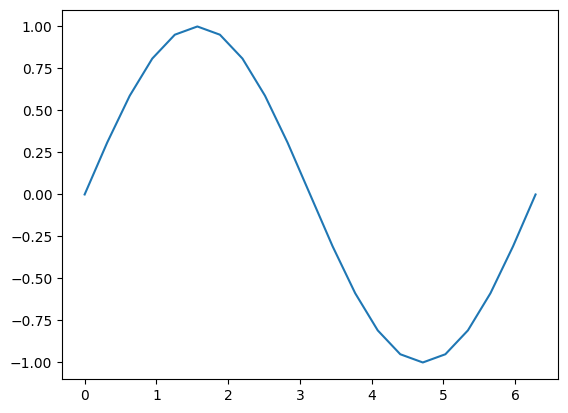

In [30]:
sample_arr_1 = np.array([1, 2, 3, 4, 5])
sample_arr_2 = np.sin(np.arange(0, 2.1*np.pi, np.pi/10))

# A figure for sample_arr_2 is plotted for your reference.
plt.plot(np.arange(0, 2.1*np.pi, np.pi/10), sample_arr_2)
plt.show()

In [43]:
# your solution to 3.
# print out d_val_1 and d_val_2 using the correct function below.
#reloading the new and updated Quiz3Fun python script
import importlib
import self_py_fun.Quiz3Fun
importlib.reload(self_py_fun.Quiz3Fun)
from self_py_fun.Quiz3Fun import *
import numpy as np

sample_arr_1 = np.array([1, 2, 3, 4, 5])
sample_arr_2 = np.sin(np.arange(0, 2.1*np.pi, np.pi/10))

d_val_1 = compute_D_correct(sample_arr_1)
d_val_2 = compute_D_correct(sample_arr_2)

print(f"d_val_1: {d_val_1:.2f}")
print(f"d_val_2: {d_val_2:.2f}")

d_val_1: 5.66
d_val_2: 20.48


## Final Remarks
<font size='4'>

1. Save all your codes and outputs.
2. Push your changes to your own GitHub repository and submit the link of your Quiz3.ipynb to Canvas.
3. If you have trouble completing the previous step, convert your Jupyter Notebook into a .html output and submit the html output to Canvas.


Finally, Happy Halloween! Remember to take the Ferrero chocolate.